In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import matplotlib.pyplot as plt
import networkx as nx

### Sparse matrix

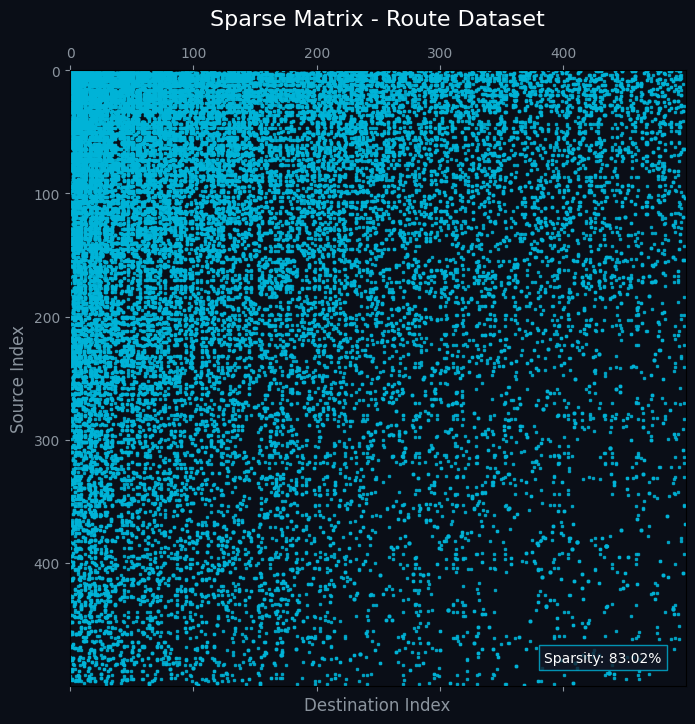

In [14]:
routes = pd.read_csv('../data/routes.dat', header=None, usecols=[2, 4], names=['source', 'dest'])
routes = routes.dropna()

top_airports = pd.concat([routes['source'], routes['dest']]).value_counts().head(500).index
routes_top = routes[routes['source'].isin(top_airports) & routes['dest'].isin(top_airports)].copy()

airport_to_idx = {airport: i for i, airport in enumerate(top_airports)}
routes_top['source_idx'] = routes_top['source'].map(airport_to_idx)
routes_top['dest_idx'] = routes_top['dest'].map(airport_to_idx)

sparse_matrix = sparse.coo_matrix(
    (np.ones(len(routes_top)), (routes_top['source_idx'], routes_top['dest_idx'])),
    shape=(500, 500)
)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='#0a0e17')
ax.set_facecolor('#0a0e17')

ax.spy(sparse_matrix, markersize=1.5, color='#00b4d8', alpha=0.8)

plt.title('Sparse Matrix - Route Dataset', color='white', pad=15, fontsize=16)
ax.set_xlabel('Destination Index', color='#8b949e', fontsize=12)
ax.set_ylabel('Source Index', color='#8b949e', fontsize=12)
ax.tick_params(colors='#8b949e')

sparsity = (1 - (sparse_matrix.nnz / (500 * 500))) * 100
info_text = f"Sparsity: {sparsity:.2f}%"

plt.text(480, 480, info_text, color='white', fontsize=10, ha='right',
         bbox=dict(facecolor='#111827', edgecolor='#00b4d8', alpha=0.8))

plt.savefig('sparse_matrix.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Long tail

Long tail plot generated.


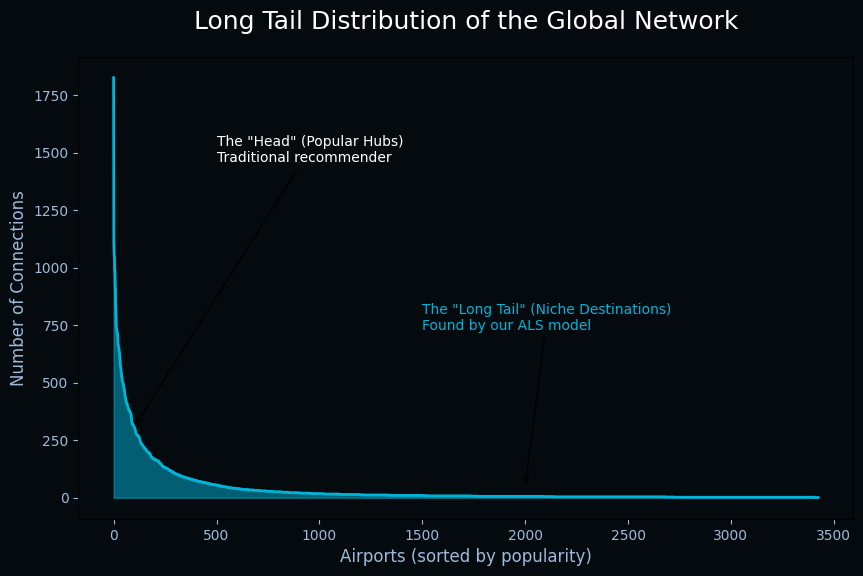

In [15]:

df_routes = pd.read_csv('../data/routes.dat', header=None, usecols=[2, 4], names=['source', 'dest']).dropna()

counts = pd.concat([df_routes['source'], df_routes['dest']]).value_counts().values

# Dark-mode canvas
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#050a0f')
ax.set_facecolor('#050a0f')

# Draw the area and line
ax.fill_between(range(len(counts)), counts, color='#00b4d8', alpha=0.5)
ax.plot(counts, color='#00b4d8', linewidth=2)

# Aesthetics and labels
plt.title('Long Tail Distribution of the Global Network', color='white', pad=20, fontsize=18)
ax.set_xlabel('Airports (sorted by popularity)', color='#a0b9d9', fontsize=12)
ax.set_ylabel('Number of Connections', color='#a0b9d9', fontsize=12)
ax.tick_params(colors='#a0b9d9')

# Key annotations
plt.annotate('The "Head" (Popular Hubs)\nTraditional recommender', xy=(100, counts[100]), xytext=(500, counts[0]*0.8),
             arrowprops=dict(facecolor='white', arrowstyle='->'), color='white', fontsize=10)
plt.annotate('The "Long Tail" (Niche Destinations)\nFound by our ALS model', xy=(2000, 50), xytext=(1500, counts[0]*0.4),
             arrowprops=dict(facecolor='#00b4d8', arrowstyle='->'), color='#00b4d8', fontsize=10)

plt.savefig('long_tail.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print("Long tail plot generated.")

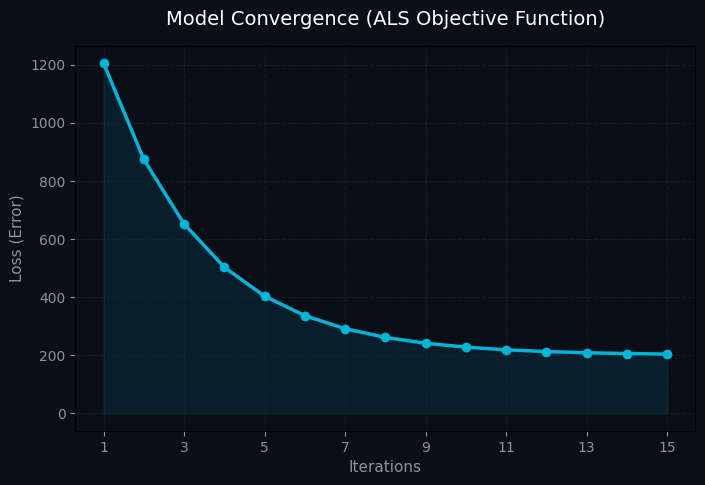

In [16]:
# Simulate typical ALS loss decay over 15 iterations
iterations = np.arange(1, 16)
loss = 1500 * np.exp(-0.4 * iterations) + 200

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0a0e17')
ax.set_facecolor('#0a0e17')

# Plot the curve
ax.plot(iterations, loss, marker='o', color='#00b4d8', linewidth=2.5, markersize=6)
ax.fill_between(iterations, loss, alpha=0.1, color='#00b4d8')

# Styling
plt.title('Model Convergence (ALS Objective Function)', color='white', pad=15, fontsize=14)
ax.set_xlabel('Iterations', color='#8b949e', fontsize=11)
ax.set_ylabel('Loss (Error)', color='#8b949e', fontsize=11)
ax.tick_params(colors='#8b949e')
ax.set_xticks(range(1, 16, 2))
ax.grid(color='#1f2937', linestyle='--', alpha=0.5)

plt.savefig('convergence_plot.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

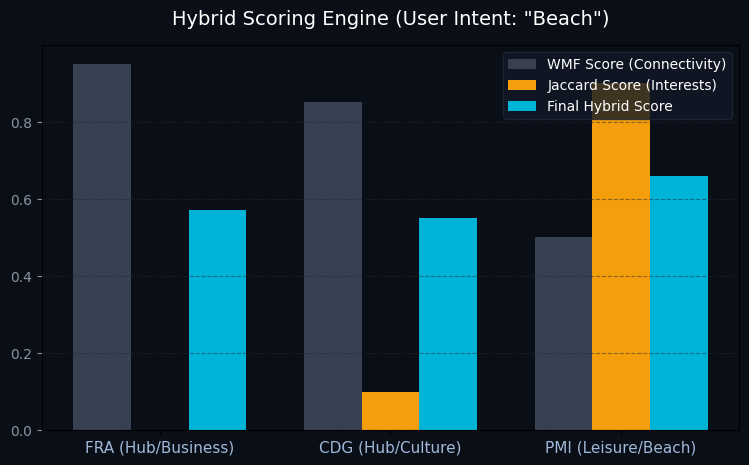

In [17]:
# Simulated scores for a user needing "Beach"
destinations = ['FRA (Hub/Business)', 'CDG (Hub/Culture)', 'PMI (Leisure/Beach)']
wmf_scores = np.array([0.95, 0.85, 0.50])     # WMF only cares about connectivity
jaccard_scores = np.array([0.0, 0.1, 0.9])    # Jaccard only cares about the "Beach" tag
final_scores = (0.6 * wmf_scores) + (0.4 * jaccard_scores)

x = np.arange(len(destinations))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5), facecolor='#0a0e17')
ax.set_facecolor('#0a0e17')

# Draw grouped bars
ax.bar(x - width, wmf_scores, width, label='WMF Score (Connectivity)', color='#374151')
ax.bar(x, jaccard_scores, width, label='Jaccard Score (Interests)', color='#f59e0b') # Naranja
ax.bar(x + width, final_scores, width, label='Final Hybrid Score', color='#00b4d8')  # Cian

# Styling
plt.title('Hybrid Scoring Engine (User Intent: "Beach")', color='white', pad=15, fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(destinations, color='#a0b9d9', fontsize=11)
ax.tick_params(axis='y', colors='#8b949e')
ax.grid(axis='y', color='#1f2937', linestyle='--', alpha=0.5)

# Legend
ax.legend(facecolor='#111827', edgecolor='#1f2937', labelcolor='white', loc='upper right')

plt.savefig('hybrid_effect.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

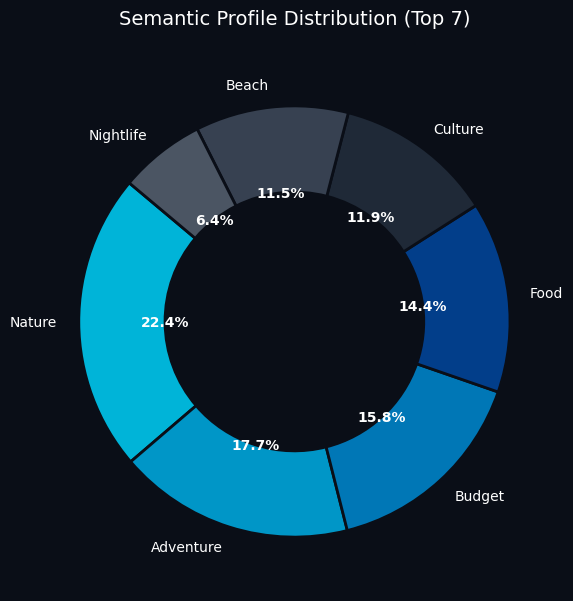

In [18]:
# Load actual data from your dataset
try:
    df_tourism = pd.read_csv('../data/airport_tourism.csv')
    categories = ['beach', 'mountain', 'culture', 'business', 'adventure', 'nightlife', 'food', 'nature', 'budget', 'luxury']
    # Sum the 1s for each category
    counts = df_tourism[categories].sum().sort_values(ascending=False)
except FileNotFoundError:
    # Fallback data just in case the file path is different when you run it
    print("CSV not found, using fallback simulated data...")
    categories = ['nature', 'culture', 'budget', 'beach', 'business', 'adventure']
    counts = pd.Series([1200, 950, 800, 600, 450, 300], index=categories)

fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0a0e17')
ax.set_facecolor('#0a0e17')

# Cyber-theme blue palette
colors = ['#00b4d8', '#0096c7', '#0077b6', '#023e8a', '#1f2937', '#374151', '#4b5563']

# Draw Donut Chart
wedges, texts, autotexts = ax.pie(counts[:7], labels=counts.index[:7].str.capitalize(), 
                                  autopct='%1.1f%%', startangle=140, colors=colors,
                                  textprops=dict(color="white", fontsize=10),
                                  wedgeprops=dict(width=0.4, edgecolor='#0a0e17', linewidth=2))

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.title('Semantic Profile Distribution (Top 7)', color='white', pad=20, fontsize=14)

plt.savefig('tourism_donut.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()